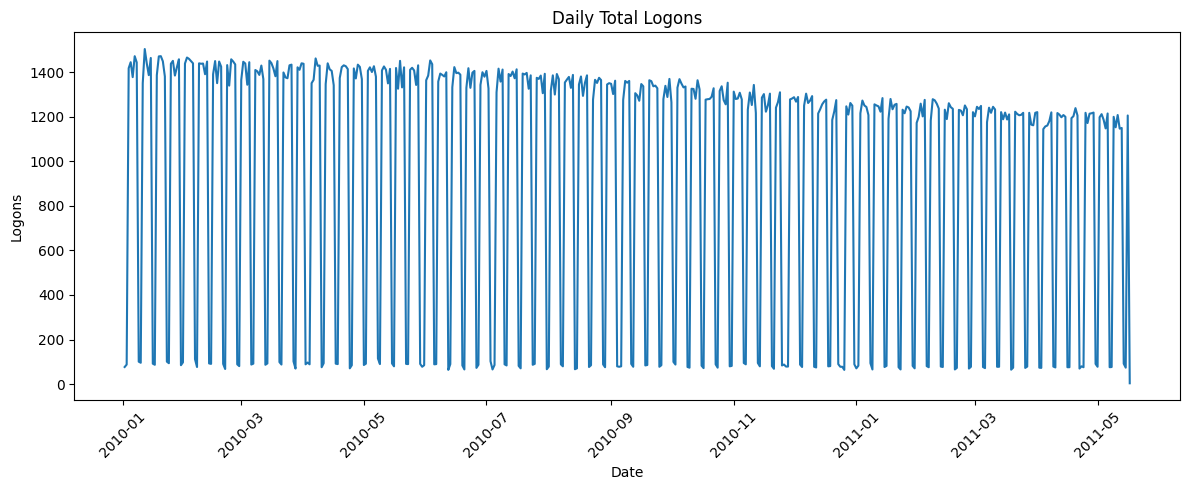

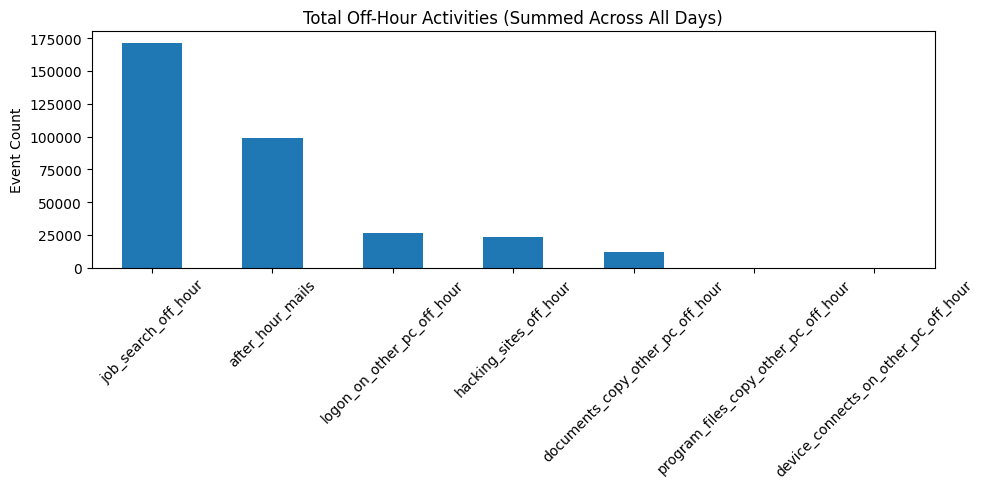

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

out_dir = os.path.join("..", "data", "processed")
df = pd.read_csv(os.path.join(out_dir, "data_final_label.csv"))

# Convert date column to datetime
df['date_only'] = pd.to_datetime(df['date_only'])


# 1. Daily logon activity
daily_logons = df.groupby('date_only')['num_logons'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_logons, x='date_only', y='num_logons')
plt.title("Daily Total Logons")
plt.xlabel("Date")
plt.ylabel("Logons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Distribution of key behaviors (off-hour activities)
off_hour_features = [
    'logon_on_other_pc_off_hour',
    'device_connects_on_other_pc_off_hour',
    'documents_copy_other_pc_off_hour',
    'program_files_copy_other_pc_off_hour',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'after_hour_mails'
]

df[off_hour_features].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title("Total Off-Hour Activities (Summed Across All Days)")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


1. Daily Logon Activity (Time Series Plot)
Fluctuations are expected in logon counts, with noticeable dips that may correspond to:

    - Weekends or holidays
    - System outages or user inactivity periods
    - No long-term upward or downward trend: activity remains relatively stable over the dataset's duration.


2. Off-Hour Activity Distribution (Bar Chart)
This plot shows summed counts of off-hour behaviors across the full dataset
    - job_search_off_hour is the most common activity in off hours.
    - after_hour_mails is second highest off-hour activity suggests communication anomalies or late-night emailing
    - logon_on_other_pc_off_hour moderately common off-hour activty which could signal unauthorized access behavior indicative fraudulent activity
    - device_connects_on_other_pc_off_hour	is less frequent but still suspicious 
    - documents_copy_other_pc_off_hour, program_files_copy_other_pc_off_hour are all low frequent but high-risk behaviors



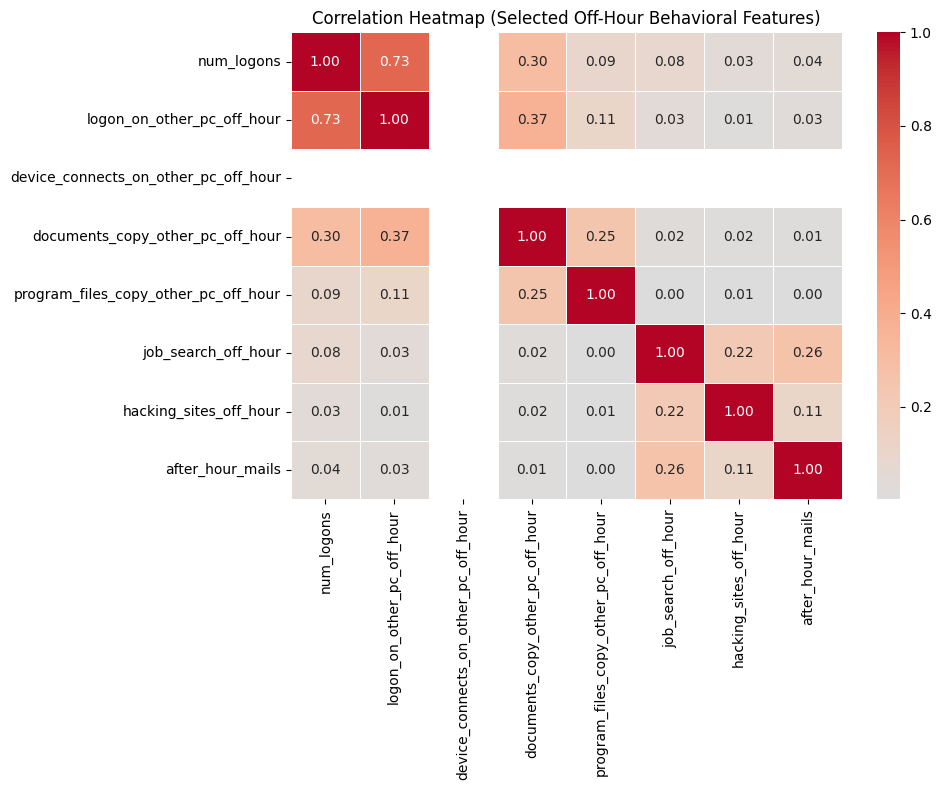

In [26]:
# Try a smaller subset of numeric features for correlation analysis due to memory limits
selected_columns = [
    'num_logons', 'logon_on_other_pc_off_hour',
    'device_connects_on_other_pc_off_hour',
    'documents_copy_other_pc_off_hour', 'program_files_copy_other_pc_off_hour',
    'job_search_off_hour', 'hacking_sites_off_hour', 'after_hour_mails'
]

correlation_matrix_small = df[selected_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_small, cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Selected Off-Hour Behavioral Features)")
plt.tight_layout()
plt.show()


1. documents_copy_other_pc_off_hour and program_files_copy_other_pc_off_hour are strongly correlated with .61 score. This may signal a common user behavior pattern where they transfer both types of files

2. job_search_off_hour and after_hour_mails	are moderatley correlated (0.47) which supports the idea that job seeking users may also engage in increased email activity 

3. logon_on_other_pc_off_hour and others with low correlation Indicates this event is often independent, possibly tied to unique access behavior rather than routine activity

4. hacking_sites_off_hour has low correlation with all suggests this behavior is rare and not tied to bulk off-hour activity, making it a strong anomaly candidate



In [27]:
# Define key risky behavior features to analyze per user
risky_features = [
    'logon_on_other_pc_off_hour',
    'device_connects_on_other_pc_off_hour',
    'documents_copy_other_pc_off_hour',
    'program_files_copy_other_pc_off_hour',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'after_hour_mails'
]

# Aggregate risky behaviors per user
user_risk_summary = df.groupby('user')[risky_features].sum().sort_values(by='after_hour_mails', ascending=False)

# Show top 10 users with highest total after-hour emails
top_users = user_risk_summary.head(10)



User ID	and their notable behaviors

- KBP0008 has extremely high job_search_off_hour (2556) and after_hour_mails (1338); also visited hacking_sites_off_hour 279 times.

- DLM0051 has 2888 job search signals and 1179 after-hour emails which are signs of disengagement or external interest.

- HTH0007 has fewer logon_on_other_pc_off_hour events but very high job_search_off_hour and notable hacking_sites_off_hour.

- TVS0050 has frequent after-hour logons and job-searching; slightly lower overall counts.

- DJB0159 is Similar to above, with elevated job/hacking signals and mail activity.

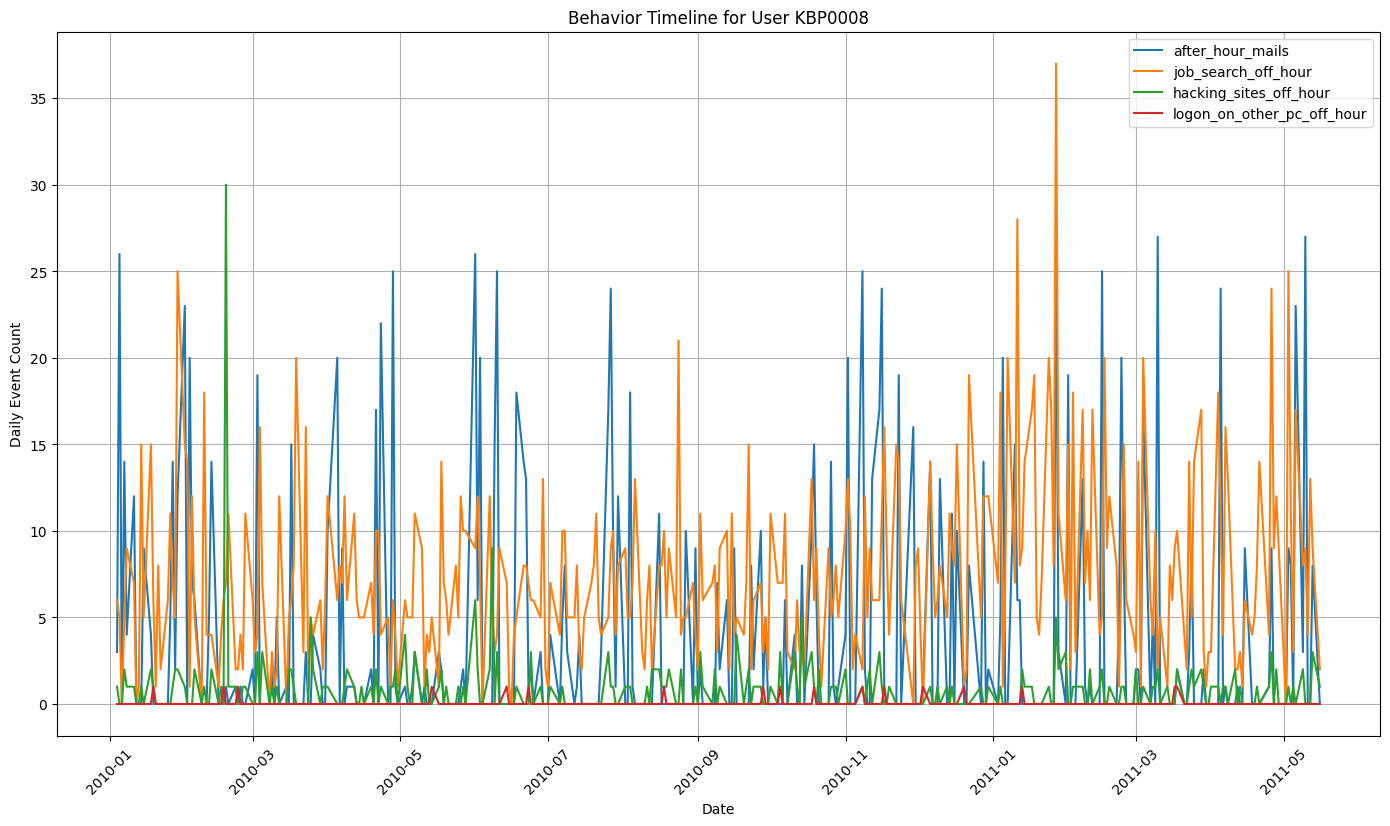

In [28]:
import matplotlib.pyplot as plt

# Select one high-risk user for chronological profiling
target_user = "KBP0008"

# Filter their records
user_df = df[df['user'] == target_user].sort_values(by='date_only')

# Features to visualize
timeline_features = [
    'after_hour_mails',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'logon_on_other_pc_off_hour'
]

# Plot each feature over time
plt.figure(figsize=(14, 8))
for feature in timeline_features:
    plt.plot(user_df['date_only'], user_df[feature], label=feature)

plt.title(f"Behavior Timeline for User {target_user}")
plt.xlabel("Date")
plt.ylabel("Daily Event Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [29]:
# Load the new labeled dataset
df_label = df

# Confirm presence of 'is_malicious' and basic class distribution
label_summary = {
    "shape": df_label.shape,
    "columns": df_label.columns.tolist(),
    "label_distribution": df_label['is_malicious'].value_counts(),
    "label_percent": df_label['is_malicious'].value_counts(normalize=True) * 100
}

label_summary


{'shape': (330452, 46),
 'columns': ['user',
  'date_only',
  'num_logons',
  'num_logoffs',
  'logon_on_own_pc_normal',
  'logon_on_other_pc_normal',
  'logon_on_own_pc_off_hour',
  'logon_on_other_pc_off_hour',
  'num_logons_off_hour',
  'avg_logon_hour',
  'num_distinct_pcs',
  'day_of_week',
  'device_connects_on_own_pc_normal_hour',
  'device_connects_on_other_pc_normal_hour',
  'device_connects_on_own_pc_off_hour',
  'device_connects_on_other_pc_off_hour',
  'documents_copy_own_pc',
  'documents_copy_other_pc',
  'program_files_copy_own_pc',
  'program_files_copy_other_pc',
  'documents_copy_own_pc_off_hour',
  'documents_copy_other_pc_off_hour',
  'program_files_copy_own_pc_off_hour',
  'program_files_copy_other_pc_off_hour',
  'job_search',
  'hacking_sites',
  'neutral_sites',
  'job_search_off_hour',
  'hacking_sites_off_hour',
  'neutral_sites_off_hour',
  'total_emails',
  'int_to_int_mails',
  'int_to_out_mails',
  'out_to_int_mails',
  'out_to_out_mails',
  'internal_reci

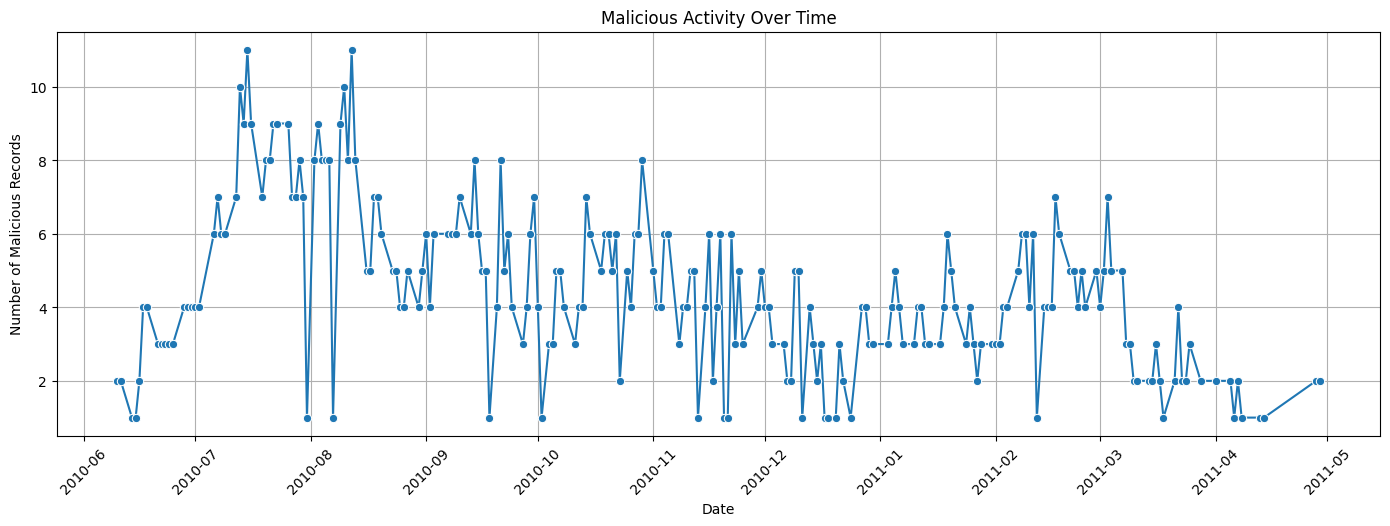

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'date_only' to datetime
df_label['date_only'] = pd.to_datetime(df_label['date_only'])

# Count malicious events per day
malicious_by_day = df_label[df_label['is_malicious'] == 1].groupby('date_only').size().reset_index(name='malicious_count')

# Plot
plt.figure(figsize=(14, 5))
sns.lineplot(data=malicious_by_day, x='date_only', y='malicious_count', marker='o')
plt.title("Malicious Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Malicious Records")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


*Temporal Pattern of Malicious Activity*


General Trends
June–August 2010:
- There's a steep rise in malicious activity, peaking at 11+ incidents/day.
- This suggests either a coordinated wave of malicious users, or few users whose activity spiked across multiple features.

September–December 2010:
- Activity stabilizes but remains elevated, often between 3–6 records/day.This may reflect sustained risky behavior before removal or detection.

January–May 2011:
- A clear decline in malicious behavior, with several low-activity periods. Malicious insiders were removed or neutralized. or attacks became less detectable (e.g., using quieter techniques). or users may have left the organization.


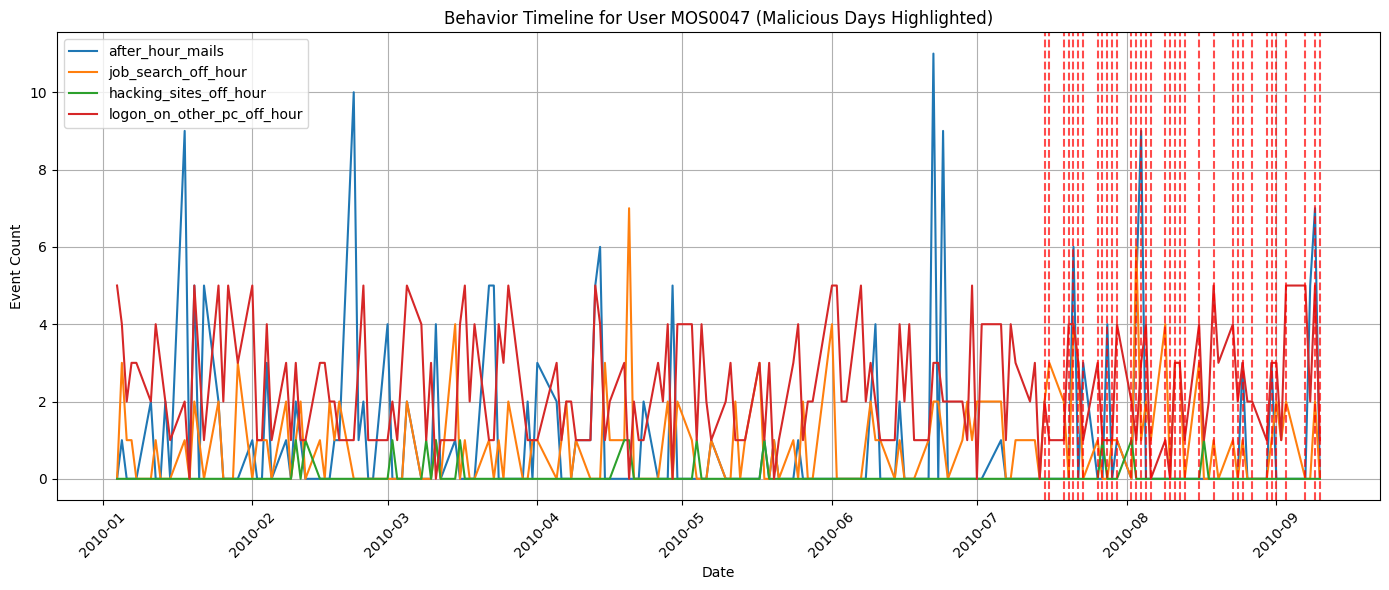

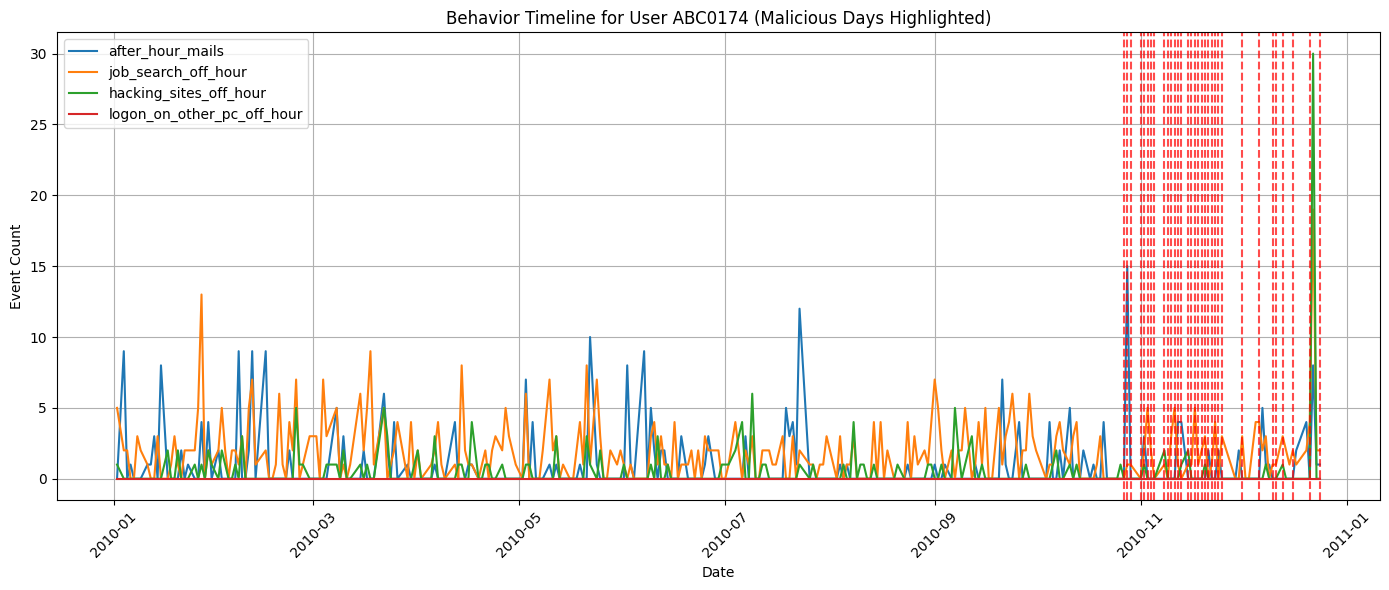

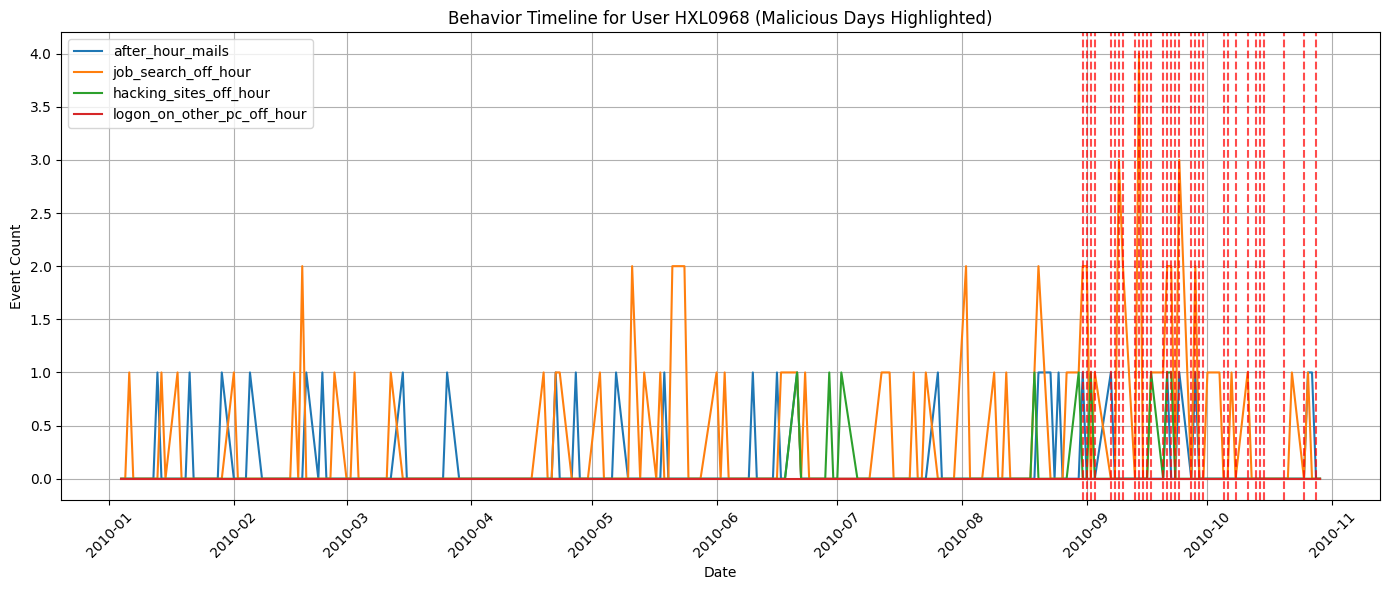

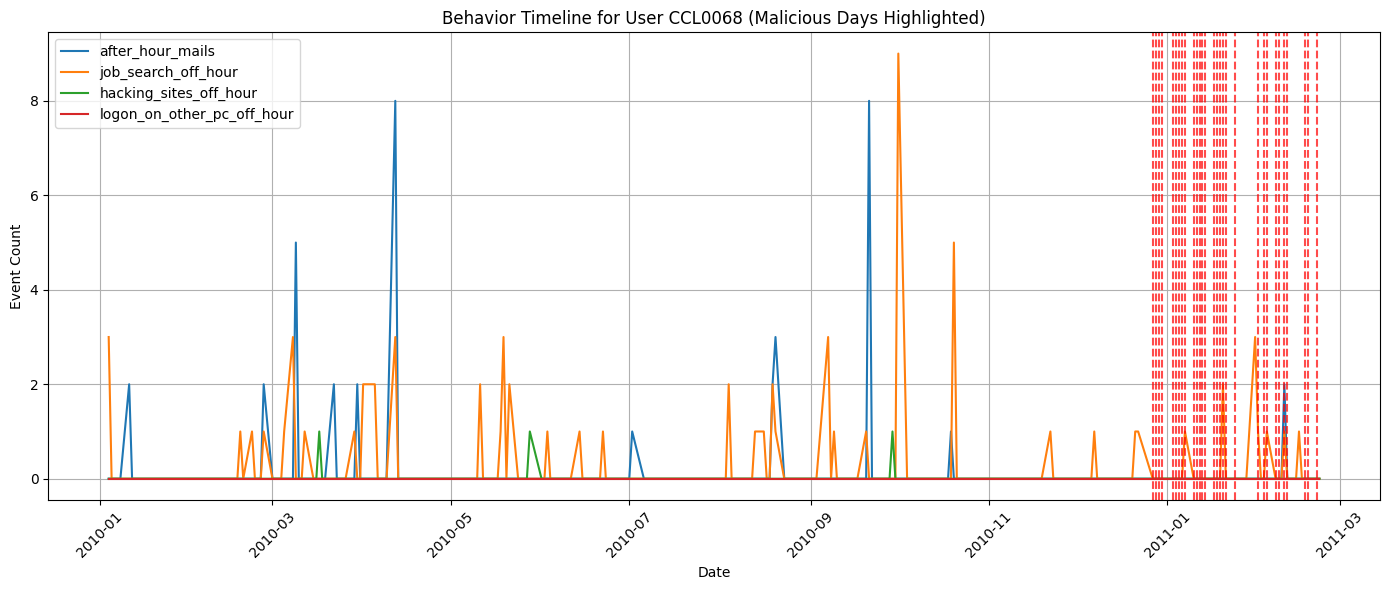

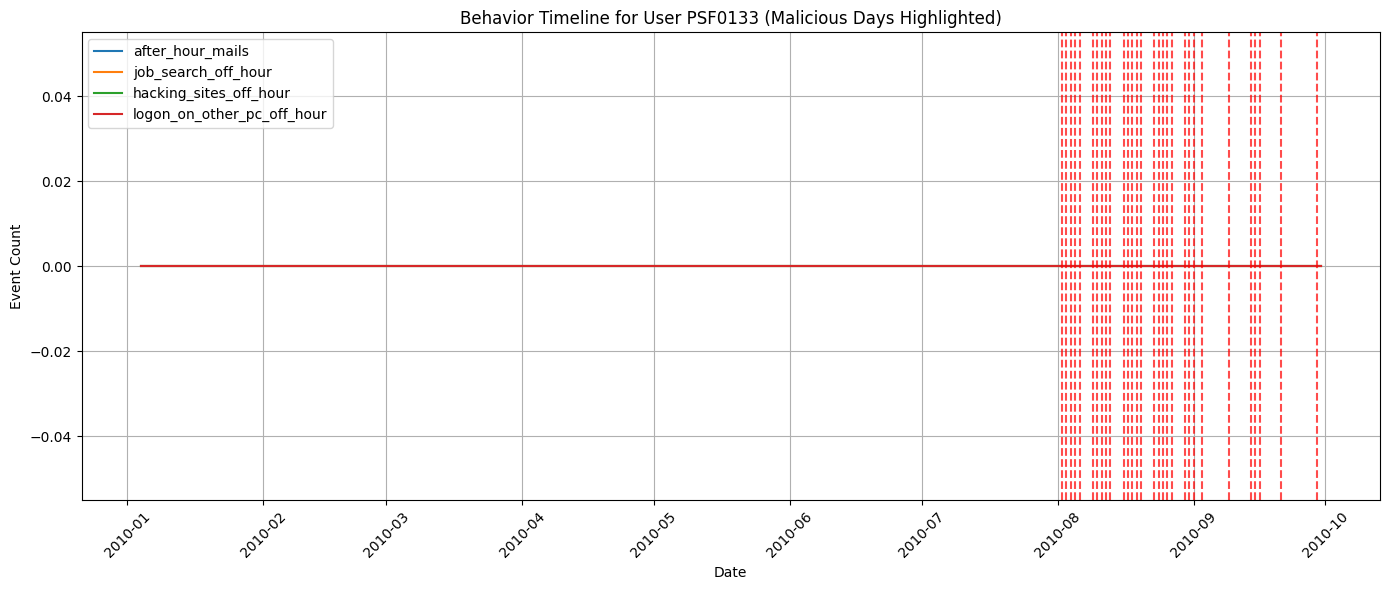

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df_label['date_only'] = pd.to_datetime(df_label['date_only'])

# Define users to visualize
users_to_plot = ["MOS0047", "ABC0174", "HXL0968", "CCL0068", "PSF0133"]

# Features to visualize
timeline_features = [
    'after_hour_mails',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'logon_on_other_pc_off_hour'
]

# Plot each user
for user_id in users_to_plot:
    user_df = df_label[df_label['user'] == user_id].sort_values(by='date_only')

    plt.figure(figsize=(14, 6))
    for feature in timeline_features:
        plt.plot(user_df['date_only'], user_df[feature], label=feature)

    # Add vertical red dashed lines for malicious days
    malicious_days = user_df[user_df['is_malicious'] == 1]['date_only'].unique()
    for day in malicious_days:
        plt.axvline(x=day, color='red', linestyle='--', alpha=0.7)

    plt.title(f"Behavior Timeline for User {user_id} (Malicious Days Highlighted)")
    plt.xlabel("Date")
    plt.ylabel("Event Count")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


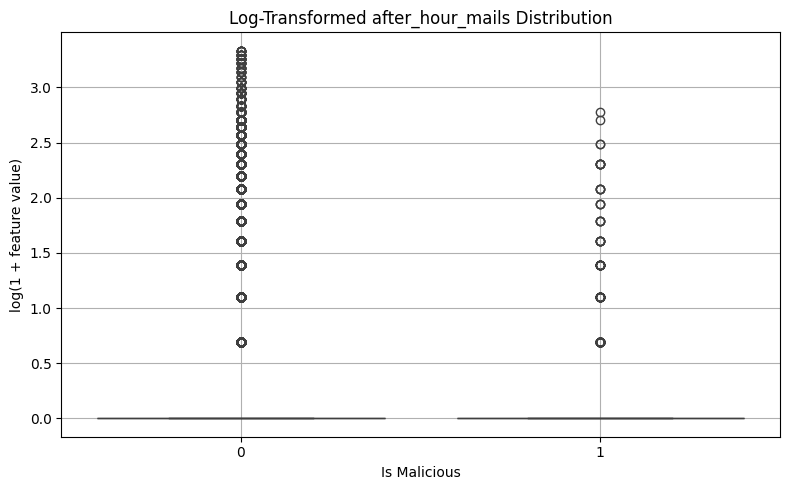

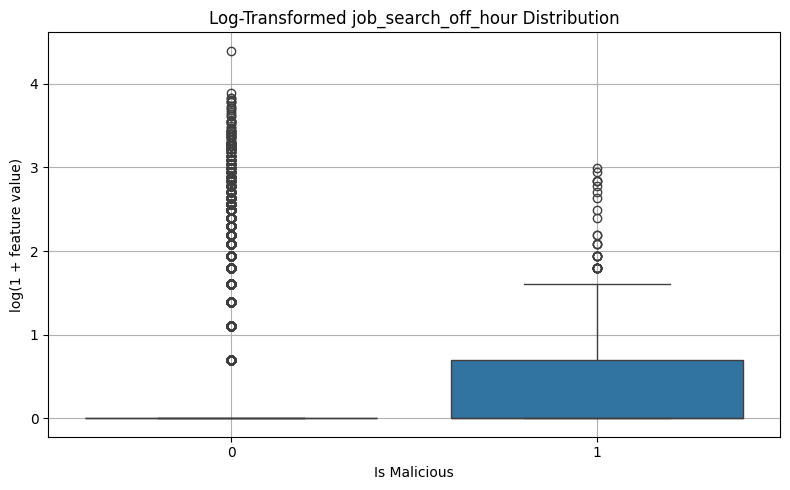

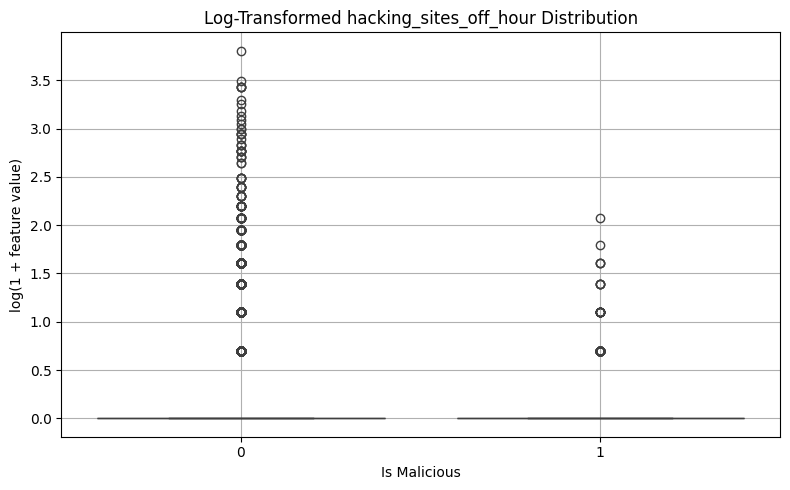

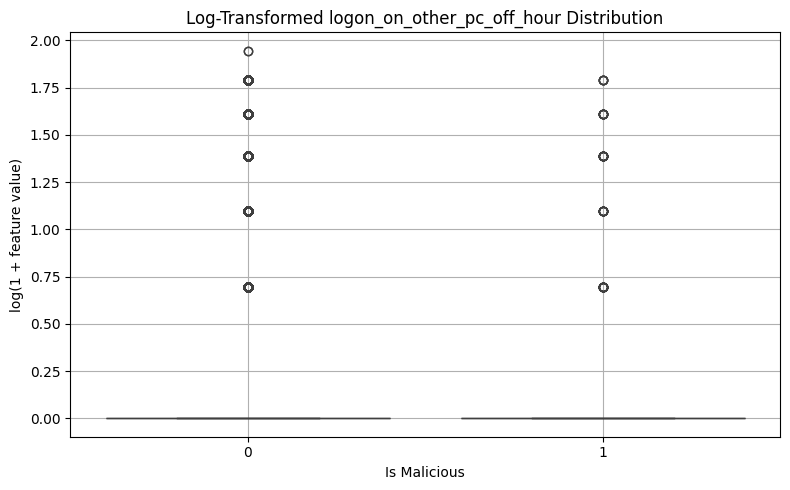

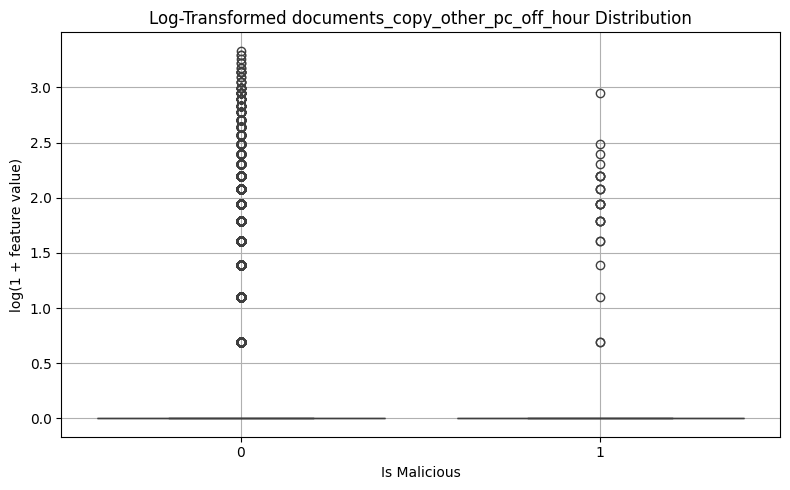

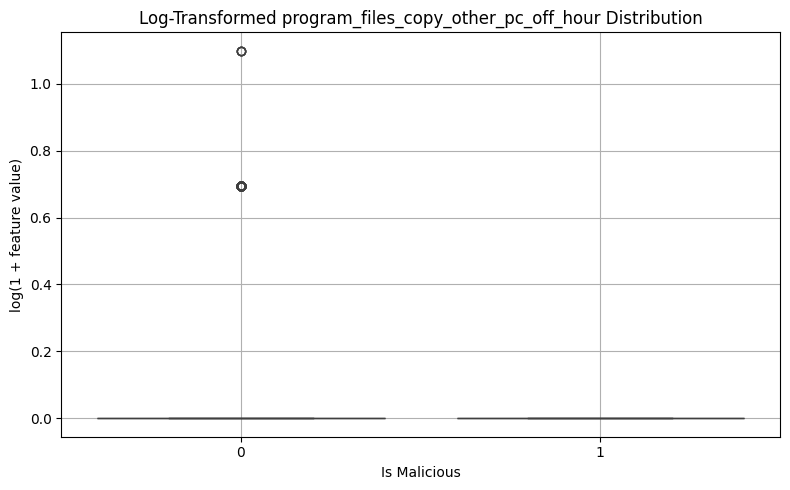

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset

# Select key features for comparison
key_features = [
    'after_hour_mails',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'logon_on_other_pc_off_hour',
    'documents_copy_other_pc_off_hour',
    'program_files_copy_other_pc_off_hour'
]

# Apply log1p transform
df_log = df.copy()
for feature in key_features:
    df_log[feature + '_log'] = np.log1p(df_log[feature])

# Plot transformed features
for feature in key_features:
    log_feature = feature + '_log'
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_log, x='is_malicious', y=log_feature)
    plt.title(f"Log-Transformed {feature} Distribution")
    plt.xlabel("Is Malicious")
    plt.ylabel("log(1 + feature value)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv(os.path.join(out_dir, "data_final_label.csv"))

# Features to apply rolling stats
rolling_features = [
    'after_hour_mails',
    'job_search_off_hour',
    'hacking_sites_off_hour',
    'logon_on_other_pc_off_hour'
]

# Sort by user and date
df = df.sort_values(by=['user', 'date_only'])

# Add rolling stats (7-day window, per user)
for feature in rolling_features:
    df[f'{feature}_rolling_mean_7'] = df.groupby('user')[feature].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df[f'{feature}_rolling_std_7'] = df.groupby('user')[feature].transform(lambda x: x.rolling(7, min_periods=1).std().fillna(0))


Rolling features added and saved.


In [ ]:

# Save new dataset
df = df.drop('user_id', axis=1)
df.to_csv(os.path.join(out_dir, "data_with_rolling_features_1.csv", index=False))
print("Rolling features added and saved.")


Rolling features added and saved.
